#Раздел 1. Управление сетью

In [ ]:
1  nmcli connection show

###Сначала смотрю доступные сети
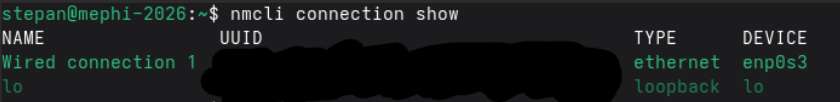

###Меня интересует подсвеченная сеть Wired connection 1

In [ ]:
2  ip a

###После этого смотрю ip этой сети. Параллельно на основной ОС (не ВМ) в командной строке вбиваю 'ipconfig', чтобы узнать основной шлюз и IPv4 адрес.

In [ ]:
3  sudo hostnamectl set-hostname mephi-2026.domain.local
4  hostnamectl

###Тут меняю  имя хоста и проверяю, что все нормально поменялось
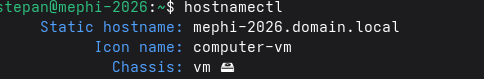

In [ ]:
5  sudo nmcli connection modify 'Wired connection 1' ipv4.addresses 192.168.0.101/24
6  sudo nmcli connection modify 'Wired connection 1' ipv4.gateway 192.168.0.1
7  sudo nmcli connection modify 'Wired connection 1' ipv4.dns '8.8.8.8'
8  sudo nmcli connection modify 'Wired connection 1' ipv4.method manual
9  sudo nmcli connection modify 'Wired connection 1' ipv4.ignore-auto-dns yes
10  sudo nmcli connection down 'Wired connection 1'
11  sudo nmcli connection up 'Wired connection 1'
12  ip addr show

###В этом блоке я меняю статистический IP, шлюз и DNS-сервера. Также, меняю метод на ручной, чтобы закрепить адрес статистически, и говорю игнорировать все прилетающие из сети DNS-адреса, чтобы мы смотрели исключительно 8.8.8.8. После чего выключаю и поднимаю заново подключение, чтобы изменения вступили в силу.

In [ ]:
13  ping -c 4 8.8.8.8 > /tmp/network_check.txt
14  ping -c 4 192.168.0.1 >> /tmp/network_check.txt
15  cat /tmp/network_check.txt

###Пингую и смотрю результат. Скажу честно: намучился с этим. Были постоянные пакет-лоссы и я не понимал в чем конкретно может быть проблема. Менял в настройках сети ВМ Сетевой мост на Виртуальный адаптер, чтобы изолировать работу, но ничего не получалось. Главная проблема в том, что, когда я только начал делать работу, я был один в квартире и всё нормально работало. Оказалось, что правильным решением было отключить и включить роутер, чтобы никакое другое устройство не застолбило за собой нужный IP.

#Раздел 2. Управление программным обеспечением

In [ ]:
16  sudo dnf install -y nginx
17  sudo dnf install -y tcpdump
18  sudo dnf install -y libcap-ng-utils

###Устанавливаю нужные по заданию пакеты

In [ ]:
19  dnf download --destdir=/tmp tcpdump
20  sudo rpm -U /tmp/tcpdump-*.rpm

###Опять делаю всё по заданию: скачиваю пакет tcpdump в директорию /tmp с помощью менеджера пакетов dnf download. Устанавливаю его с помощью команды rpm.

#Раздел 3. Управление файловыми системами и сервисами

In [ ]:
21  lsblk

###Тут заранее потребовалось "подключить" жесткий диск в настройках ВМ. Командой lsblk проверяю его наличие (вернее, смотрю на вывод команды и пытаюсь найти диск sdb глазами).

In [ ]:
22  sudo fdisk /dev/sdb
n
p
1
enter
enter
w

###Далее создаю раздел на всем диске. Для этого использую интерактивное меню fdisk, команды для которого я так же написал в ячейке.
###Сначала создаю новый раздел, делаю его основным, присваиваю номер, дважды нажимаю enter, когда спрашивают про размер раздела (чтобы он занял всё место на диске) и сохраняю все изменения

In [ ]:
23  sudo mkfs.ext4 -L MEPHI_DATA /dev/sdb1
24  sudo mkdir -p /data/mephi-web

###Форматирую созданный раздел, как файловую систему ext4 с меткой тома MEPHI_DATA, и создаю директорию для монтирования mephi-web.

In [ ]:
25  echo 'LABEL=MEPHI_DATA  /data/mephi-web  ext4  defaults  0  2' | sudo tee -a /etc/fstab
26  sudo mount -a
27  sudo systemctl daemon-reload
28  sudo mount -a
29  df -h | grep mephi

###Настраиваю автоматическое монтирование: подключаю MEPHI_DATA к mephi-web, пишу тип файловой системы, ставлю дефолтные настройки, отключаю резервное копирование и говорю, что проверять диск на ошибки при загрузке во вторую очередь. Скажу честно, про служебные цифры, связанные с резервным копированием, и очередью на проверку подсказала нейросеть, так как я не очень понимал, почему изначальная команда не хотела нормально работать. Возможно, проблема была в том, что я изначально не делал reload.
###Итак, после того, как я настроил автоматическое монтирование, я попытался примонтировать раздел. Ничего не получилось. Я сделал reload. Все нормально примонтировалось, и df -h | grep mephi я написал, чтобы точно в этом убедиться.
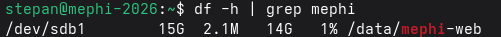

In [ ]:
30  sudo systemctl start nginx
31  sudo systemctl enable nginx
32  sudo journalctl -u nginx --since '5 minutes ago' > /tmp/nginx_recent_logs.txt
33  cat /tmp/nginx_recent_logs.txt

###Запускаю веб-сервер. Настраиваю автоматический запуск при загрузке системы. Формирую логи и смотрю их. На скрине представлено не то, что я видел, когда делал всё впервые. В самом начале там писало только о том, что nginx.service запускается (обвел).
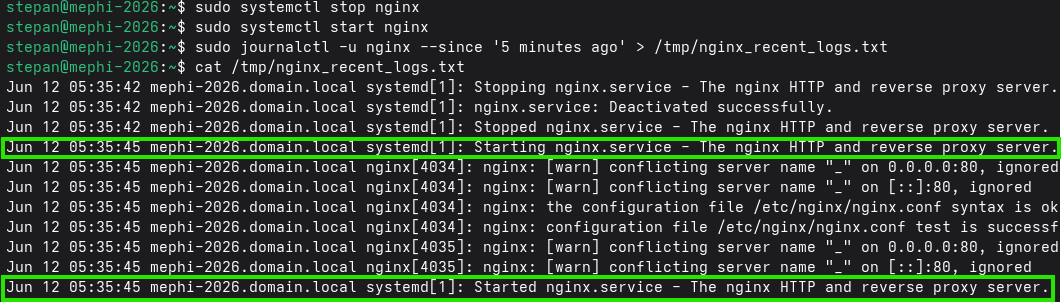

In [ ]:
34  sudo groupadd mephi-devs
35  sudo useradd -m -G mephi-devs mephi-admin
36  sudo passwd mephi-admin
P@ssw0rd2026
P@ssw0rd2026

#Раздел 4. Управление доступом

###Создаю группу mephi-devs, добавляю в неё mephi-admin и устанавливаю ему пароль

In [ ]:
37  sudo visudo
mephi-admin ALL=(ALL) ALL
ctrl + o
enter
ctrl + x

###Далее, открываю sudoers для редактирования и добавляю строчку mephi-admin ALL=(ALL) ALL в конец файла, чтобы дать все права mephi-admin в системе. Сейчас понимаю, что действие плохое, так как можно было выдать только определенные права, но на момент выполнения не задумался об этом. Прошу прощения.
###На скрине как раз видно, что я просто скопировал команду для root, но заменил юзера.
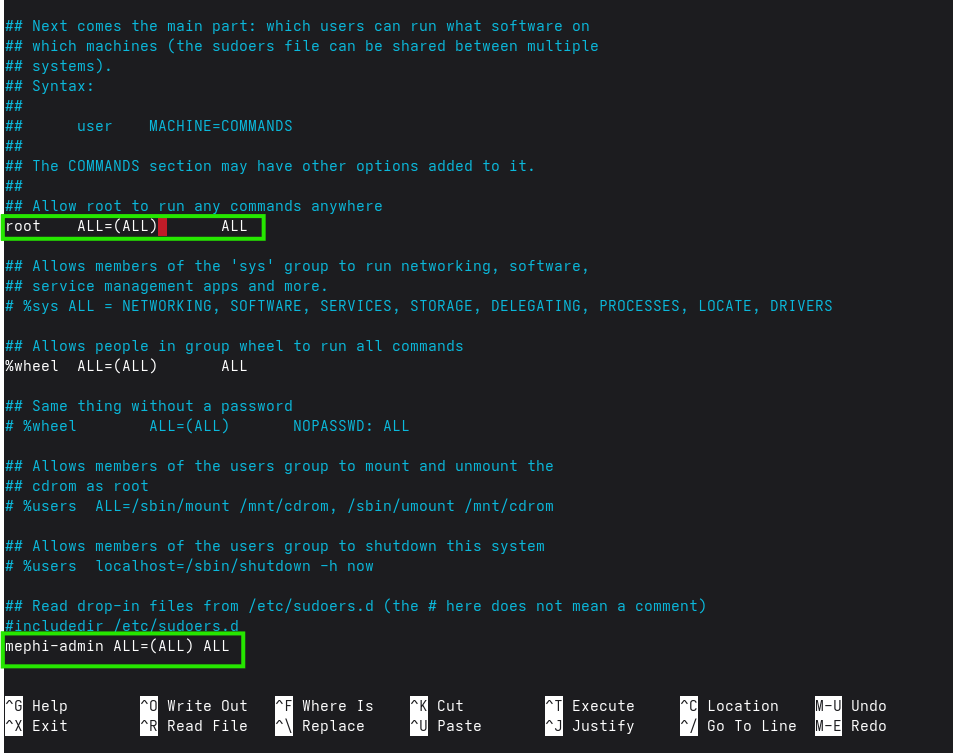
###После чего нажал ctrl + o и enter, чтобы сохранить изменения, и ctrl + x, чтобы выйти.

In [ ]:
38  sudo chown mephi-admin:mephi-devs /data/mephi-web
39  sudo chmod 2775 /data/mephi-web

###Тут меняю владельца директории и устанавливаю на неё права 2775, чтобы было наследование и полный доступ.


In [ ]:
40  sestatus
41  sudo semanage fcontext -a -t httpd_sys_content_t '/data/mephi-web(/.*)?'
42  sudo restorecon -Rv /data/mephi-web

###Настраиваю мандатное управление доступом. Смотрю статус. Делаю новое правило: httpd_sys_content_t - контент веб-сервера, который можно только читать + это распространяется на папку mephi-web и все её содержимое. Фрагмент "(/.*)?" подсказала нейросеть, так как я не понимал, почему просто "/data/mephi-web" не работает. Потом понял, что метка применилась только к папке, а все её содержимое осталось без неё. Потом написал "/data/mephi-web(/.*)" и оказалось, что теперь метка применилась только для вложенных файлов. В общем, проблемный момент.
###После всего этого рекурсивно прохожусь по вложенным директориям и, с помощью флага -v, вывожу на экран список всех файлов, которые подверглись изменению.

In [ ]:
43  sudo chmod u-s /usr/sbin/tcpdump
44  sudo setcap cap_net_raw,cap_net_admin+ep /usr/sbin/tcpdump
45  sudo -u mephi-admin tcpdump --help

###Чтобы обычный пользователь мог запустить tcpdump, снимаю SUID-бит. Далее, с помощью setcap добавляю capabilities: cap_net_raw и cap_net_admin с флагом +ep. Потом проверяю, что доступ есть.
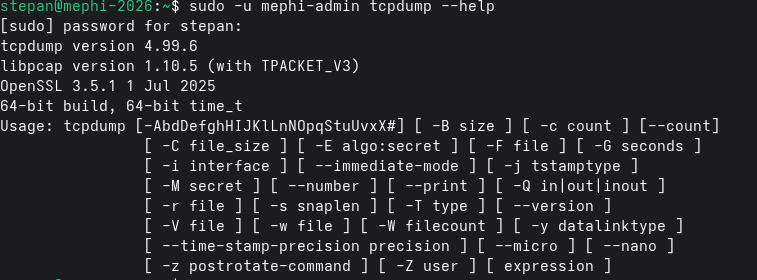

#Раздел 5. Аутентификация и итоговая проверка

In [ ]:
47  sudo chmod 644 /etc/security/denied_users
48  echo 'auth required pam_listfile.so item=user sense=deny file=/etc/security/denied_users onerr=succeed' | sudo tee -a /etc/pam.d/sshd
49  echo 'auth required pam_listfile.so item=user sense=deny file=/etc/security/denied_users onerr=succeed' | sudo tee -a /etc/pam.d/login
50  sudo systemctl restart sshd

###Меняю аутентификацию в соответствии с заданием "Настройте  аутентификацию таким образом, чтобы пользователь root НЕ МОГ войти в систему ни через локальную консоль, ни через SSH. Все остальные пользователи должны иметь возможность входить в систему."
###Добавляю проверку списка запрещенных пользователей для входа в систему локально и через SSH. Перезагружаю демона sshd, чтобы настройки вступили в силу.

In [ ]:
history > ~/project_history_stepan_launch.txt

###Этой команды не было в финальном файле истории. Это связано с тем, что на этом моменте я хотел выгрузить историю от имени юзера stepan, так как далее всё будет выполняться от имени mephi-admin, а он будет иметь свою историю. Надеюсь, что отстутствие этой команды простительно.

In [ ]:
51  su - mephi-admin
P@ssw0rd2026
52  echo 'Hello from Student: 255981' > /data/mephi-web/index.html
53  sudo restorecon -v /data/mephi-web/index.html
P@ssw0rd2026
54  sudo firewall-cmd --permanent --add-service=http
55  sudo firewall-cmd --reload
56  sudo firewall-cmd --list-all

###Вхожу под юзером mephi-admin, вводу пароль и создаю файл index.html, который содержит номер зачётной книжки. С помощью restorecon применяю мандатное управление доступом к новому файлу, с помощью флага -v вывожу на экран список всех файлов, которые подверглись изменению.
###Открываю доступ к серверу по протоколу http, меняя файрвол. Делаю его перманентным, чтобы перезагрузка ничего не поломала. Перезагружаю его, чтобы изменения применились и проверяю наличие http в сервисах.
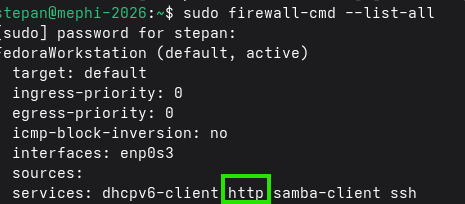

In [ ]:
57  sudo tee /etc/nginx/conf.d/mephi-web.conf << 'EOF'
server {
    listen 80 default_server;
    listen [::]:80 default_server;
    server_name _;

    root /data/mephi-web;
    index index.html index.htm;

    location / {
        try_files $uri $uri/ =404;
    }

    access_log /var/log/nginx/mephi-access.log;
    error_log /var/log/nginx/mephi-error.log;
}
EOF

###Пишу конфигурацию, которая будет заканчиваться на слове EOF. Сначала говорю слушать запросы на порте 80 для IPv4 и IPv6. Ставлю заглушку server_name _, чтобы отклик был по IP-адресу сервера, а не по домену. Указываю, где лежат файлы сайта. Пишу главный файл, который должен открыться (index.html). Тем не менее, нейросеть подсказала, что это может быть узким моментом, так как (цитирую) "Исторически сложилось так, что index.htm — это просто альтернативное (сокращенное) расширение для точно такого же файла index.html.", поэтому нужно добавить и второй файл. Тут я, честно, слепо поверил. Надеюсь, что это правда, хотя мне это кажется странным. Конечно, мы тут не занимаемся оптимизацией и прочим, но действительно ли есть смысл добавлять название второго файла, если его в природе (в этой папке) не существует....?
###Пишу location, чтобы при любой попытке пользователя что либо запросить - возвращалась стандартная 404 Not Found.
###Логирую все посещения и ошибки и завершаем конфигурацию нашим волшебным словом 'EOF', чтобы завершить конструкцию.

In [ ]:
58  sudo mv /etc/nginx/conf.d/default.conf /etc/nginx/conf.d/default.conf.bak 2>/dev/null || true
59  sudo mv /etc/nginx/default.d/welcome.conf /etc/nginx/default.d/welcome.conf.bak 2>/dev/null || true
60  sudo nginx -t
61  sudo systemctl reload nginx

###Отключаю стандартные настройки. Без них дефолтный конфиг забирал себе все запросы и показывал только "Welcome to nginx". На всякий случай ещё прописываю 2>/dev/null || true, чтобы из-за каких-либо ошибок/различий в файлах и прочем программа не останавливала своё выполнение. Ошибка удаляется, делаю вид, что ничего не произошло и надеюсь на чудо, что всё будет работать.
###Проверяем синтаксис. Он ругается на заглушку, но в целом всё хорошо, successful.
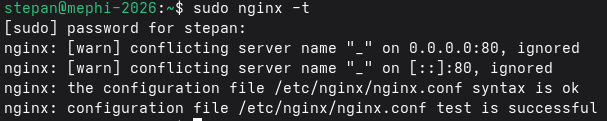
###Перезагружаем для того, чтоб настройки применились

In [ ]:
62  sudo restorecon -Rv /data/mephi-web

###Как и раньше применяем SELinux к новому файлу.

In [ ]:
63  curl http://localhost
64  curl http://192.168.0.101

###Проверяем доступность. Всё выводится. Скрин взял из финального пакета файлов.
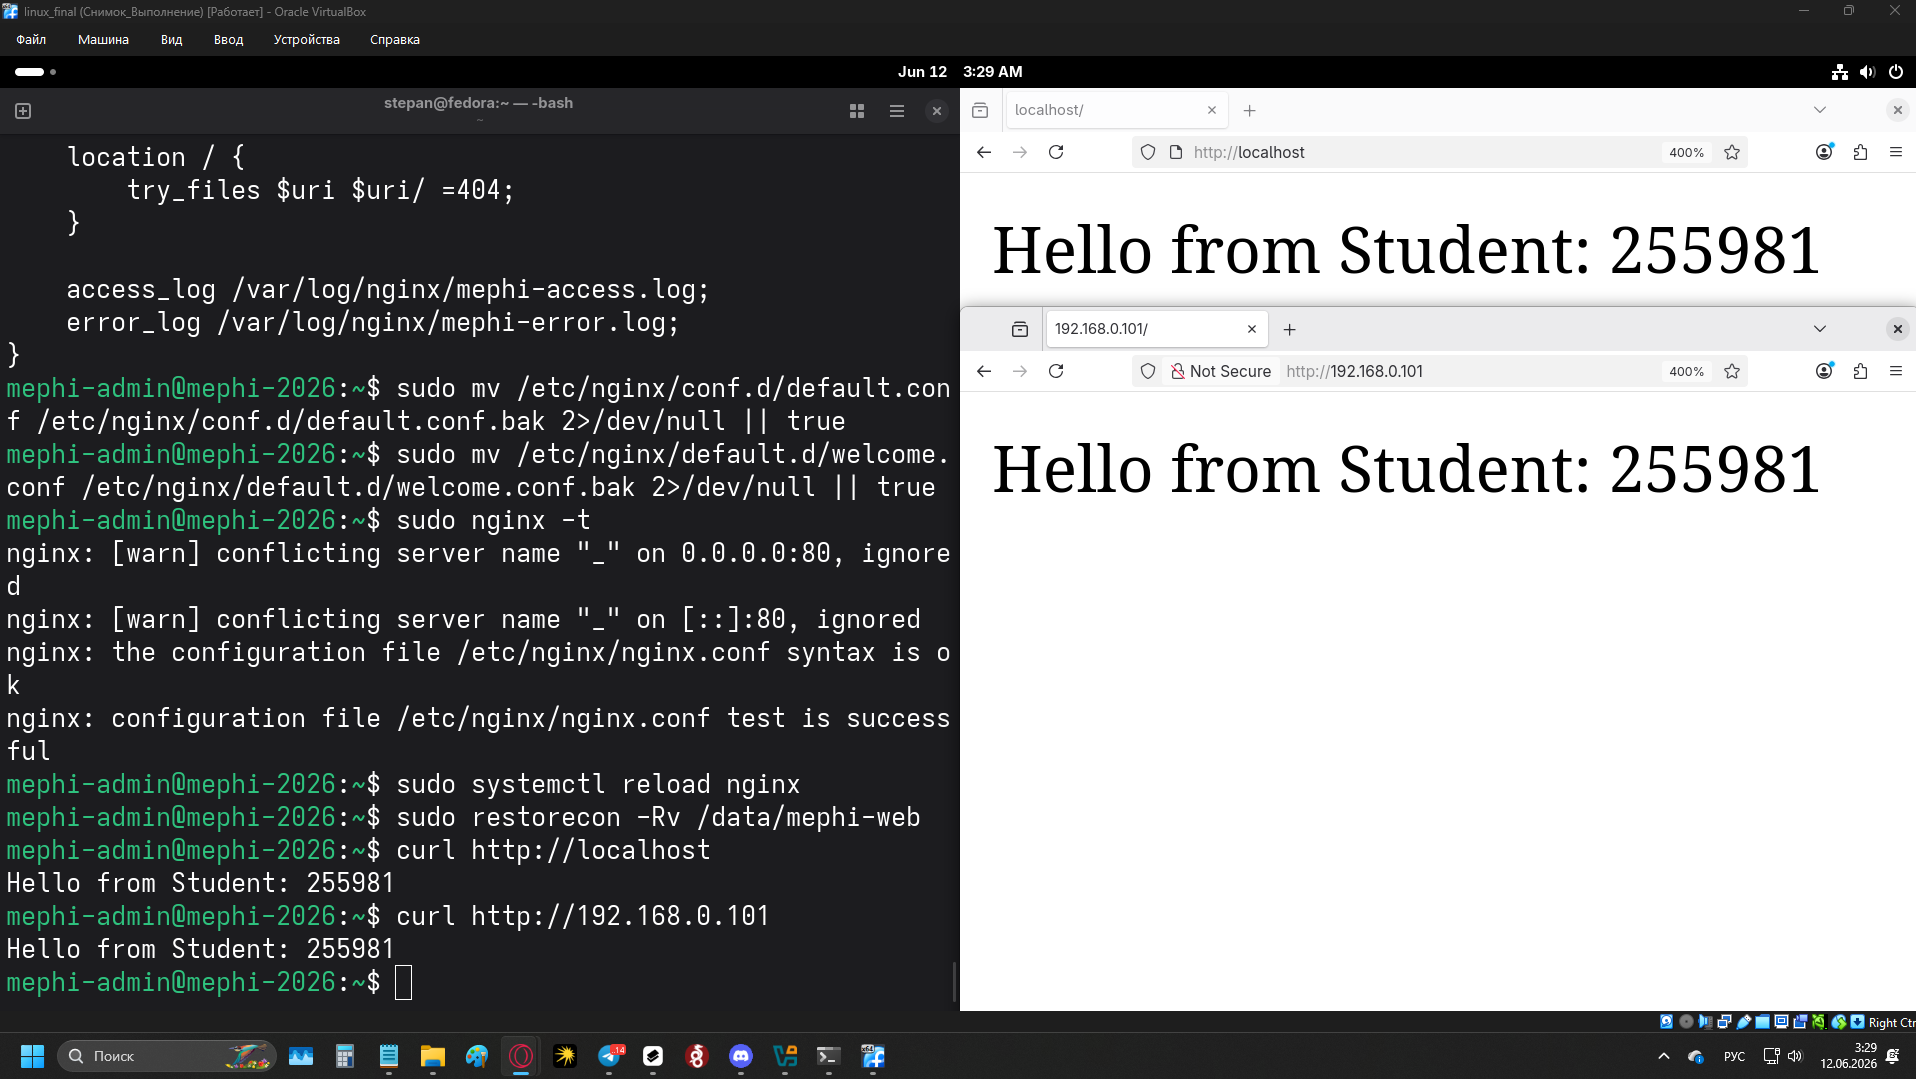

In [ ]:
history > ~/project_history_mephi-admin.txt

###Этой команды тоже не было в финальном файле с историей. Тут я просто сохраняю все команды, которые я ввёл под mephi-admin, чтобы потом нормально совместить всё в итоговый project_history.

###Спасибо за Ваше внимание и прочтение этого Коллаба. Надеюсь, своими объяснениями я смог хотя бы немного ответить на Ваши вопросы, которые могли возникнуть в ходе проверки.

###На всякий случай прикреплю настройки своей ВМ.
1. Добавленный диск
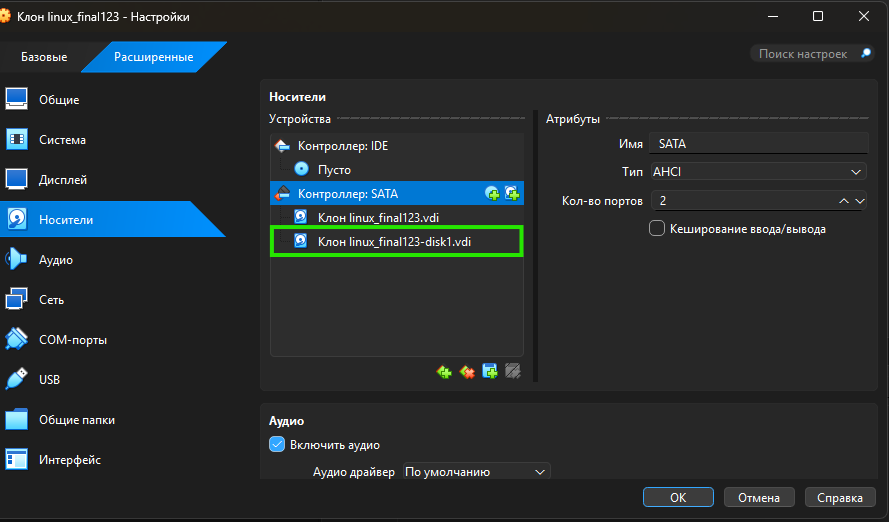
2. Настройки сети
 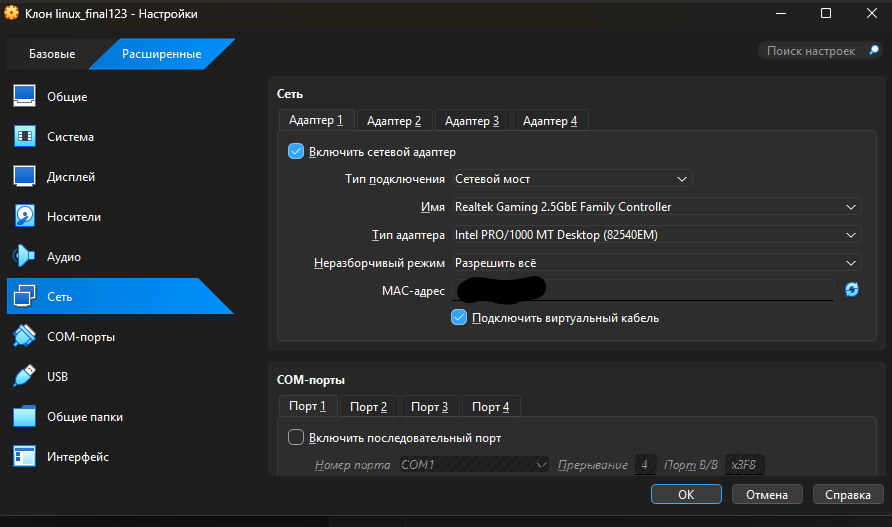